Simulates asset prices with GBM

In [53]:
import numpy as np
import matplotlib.pyplot as plt

Parameters

In [54]:
S0    = 100    # initial price
mu    = 0.0   # annual return/drift
sigma = 0.20   # annual volatility 
T     = 1.0    # time horizon
N     = 252    # time steps (number of trading days)
I     = 20     # number of simulated paths

np.random.seed(195261)

Simulation function

In [55]:
def gbm_simulate(S0, mu, sigma, T, N, I):
    dt = T/N # time step length
    times = np.linspace(0, T, N+1) # array of times
    S = np.zeros((N+1, I)) # matrix to store asset values
    S[0] = S0

    for t in range (1, N+1):
        Z = np.random.standard_normal(I) # array of length I of normally distrubuted noise
        S[t] = S[t-1] * np.exp((mu - 0.5*sigma**2) * dt + sigma * np.sqrt(dt) * Z) # discretised closed form of GBM
    return S, times
    

Run function

In [56]:
S, times = gbm_simulate(S0, mu, sigma, T, N, I)

print(f"Starting price   : ${S[0, 0]:.2f}")
print(f"Mean final price : ${S[-1].mean():.2f}")
print(f"Min  final price : ${S[-1].min():.2f}")
print(f"Max  final price : ${S[-1].max():.2f}")


Starting price   : $100.00
Mean final price : $97.43
Min  final price : $69.12
Max  final price : $139.81


Plot paths

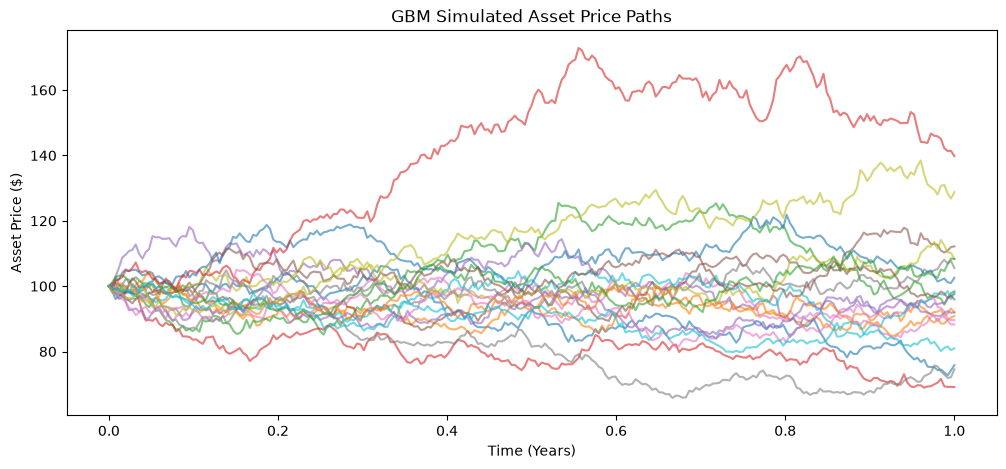

In [57]:
plt.figure(figsize=(12, 5))
plt.plot(times, S, alpha=0.6)


plt.title("GBM Simulated Asset Price Paths")
plt.xlabel("Time (Years)")
plt.ylabel("Asset Price ($)")
plt.show()